In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.stattools import adfuller, kpss
from numpy.linalg import cond

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)


In [2]:
# ── 경로 수정 필요 ─────────────────────────────────
SENT_PATH = Path("../data/Sentiment_Final/sentiment_avg_7d_final.csv")
BASE_PATH = Path("../data/Finance_Final/dataset4_derived_full_with_dummies.csv")  # 기존 유가 모델 변수 CSV
# ──────────────────────────────────────────────────

sent_df = pd.read_csv(SENT_PATH, parse_dates=["date"])
base_df = pd.read_csv(BASE_PATH, parse_dates=["date"])

# sent_ 로 시작하는 감성점수 변수만 사용 (news_*, nonews_* 제외)
sent_keep = ["date"] + [c for c in sent_df.columns if c.startswith("sent_")]
sent_df = sent_df[sent_keep]

print(f"sent_df: {sent_df.shape}, {sent_df['date'].min().date()} ~ {sent_df['date'].max().date()}")
print(f"base_df: {base_df.shape}, {base_df['date'].min().date()} ~ {base_df['date'].max().date()}")

df = base_df.merge(sent_df, on="date", how="inner").sort_values("date").reset_index(drop=True)
print(f"merged : {df.shape}, {df['date'].min().date()} ~ {df['date'].max().date()}")

sent_df: (6810, 5), 2007-08-09 ~ 2026-03-31
base_df: (4548, 44), 2008-01-31 ~ 2026-03-16
merged : (4548, 48), 2008-01-31 ~ 2026-03-16


In [3]:
# ── 모델링 피처 정의 (모델링1 final_features + 감성 4개) ──
CATEGORIES = ["supply", "demand", "geopolitical", "financial"]

# 감성 보조피처 4개
sentiment_all = [f"sent_{c}_7d" for c in CATEGORIES]

# base: 모델링1에서 확정한 final_aic_features 19개 (고정, AIC 재선택 안 함)
ff = json.load(open("../outputs/baseline/final_features.json"))
base_cols = ff["final_aic_features"]
TARGET     = ff["target"]
SPLIT_DATE = ff["split_date"]

model_cols = base_cols + sentiment_all  # 19 + 4 = 23

print(f"base ({len(base_cols)}): {base_cols}")
print(f"sentiment ({len(sentiment_all)}): {sentiment_all}")
print(f"target: {TARGET} | split_date: {SPLIT_DATE}")

# 모델링에 쓸 컬럼 + 타겟만 남기고, 양쪽 데이터가 모두 있는 날짜로 정리
df = (
    df[["date"] + model_cols + [TARGET]]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)
print(f"\n분석 데이터: {df.shape}, {df['date'].min().date()} ~ {df['date'].max().date()}")


base (19): ['OilPrice', 'RealInterestRate', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'TreasuryYield', 'oil_diff_lag1', 'MA_ratio', 'MA_5_gt_MA_20', 'vix_high', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_opec_cut']
sentiment (4): ['sent_supply_7d', 'sent_demand_7d', 'sent_geopolitical_7d', 'sent_financial_7d']
target: oil_diff_target | split_date: 2022-07-20

분석 데이터: (4547, 25), 2008-01-31 ~ 2026-03-13


## 모델링 전 EDA — 감성 보조피처 점검

base 19개 거시/파생 변수는 `EDA_1st~3rd`에서 이미 검토했으므로,
여기서는 모델링2에 새로 들어오는 **감성 보조피처 4개**를 중심으로 점검한다.

1. 기초 통계 & 커버리지
2. 분포
3. 시계열 (위기 구간 대비)
4. 정상성 검정 (ADF / KPSS, train 구간 기준)
5. 타겟과의 관계


In [4]:
# ── EDA 1. 감성 피처 기초 통계 & 커버리지 ──
display(df[sentiment_all].describe().T)

# 모델 구간 내 감성점수 0(뉴스 없는 날) 비율
zero_ratio = (df[sentiment_all] == 0).mean().rename("zero_ratio").round(4)
print("감성점수 = 0 (뉴스 없는 날) 비율:")
display(zero_ratio.to_frame())


,count,mean,std,min,25%,50%,75%,max
sent_supply_7d,4547.0,-0.063252,0.381277,-0.965290,-0.210939,0.000000,0.082312,0.934526
sent_demand_7d,4547.0,-0.034064,0.397084,-0.964134,-0.198490,0.000000,0.132967,0.934614
sent_geopolitical_7d,4547.0,-0.140046,0.249941,-0.960623,-0.292935,-0.130621,0.015075,0.932697
sent_financial_7d,4547.0,-0.109840,0.368489,-0.965246,-0.316328,-0.046166,0.075085,0.934224


감성점수 = 0 (뉴스 없는 날) 비율:


,zero_ratio
sent_supply_7d,0.2122
sent_demand_7d,0.1938
sent_geopolitical_7d,0.0081
sent_financial_7d,0.0838


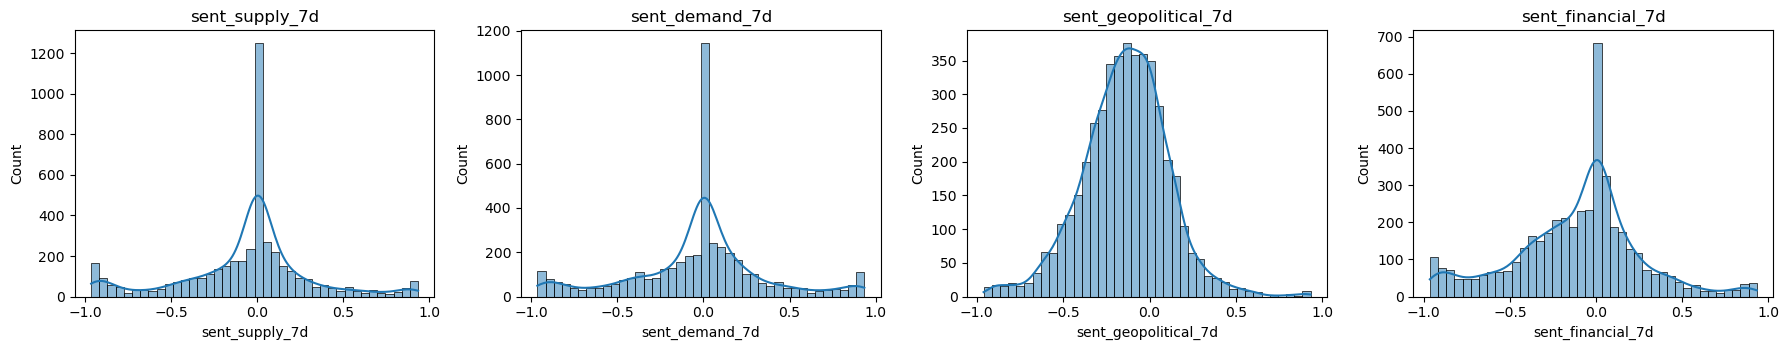

In [5]:
# ── EDA 2. 감성 피처 분포 ──
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, col in zip(axes, sentiment_all):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


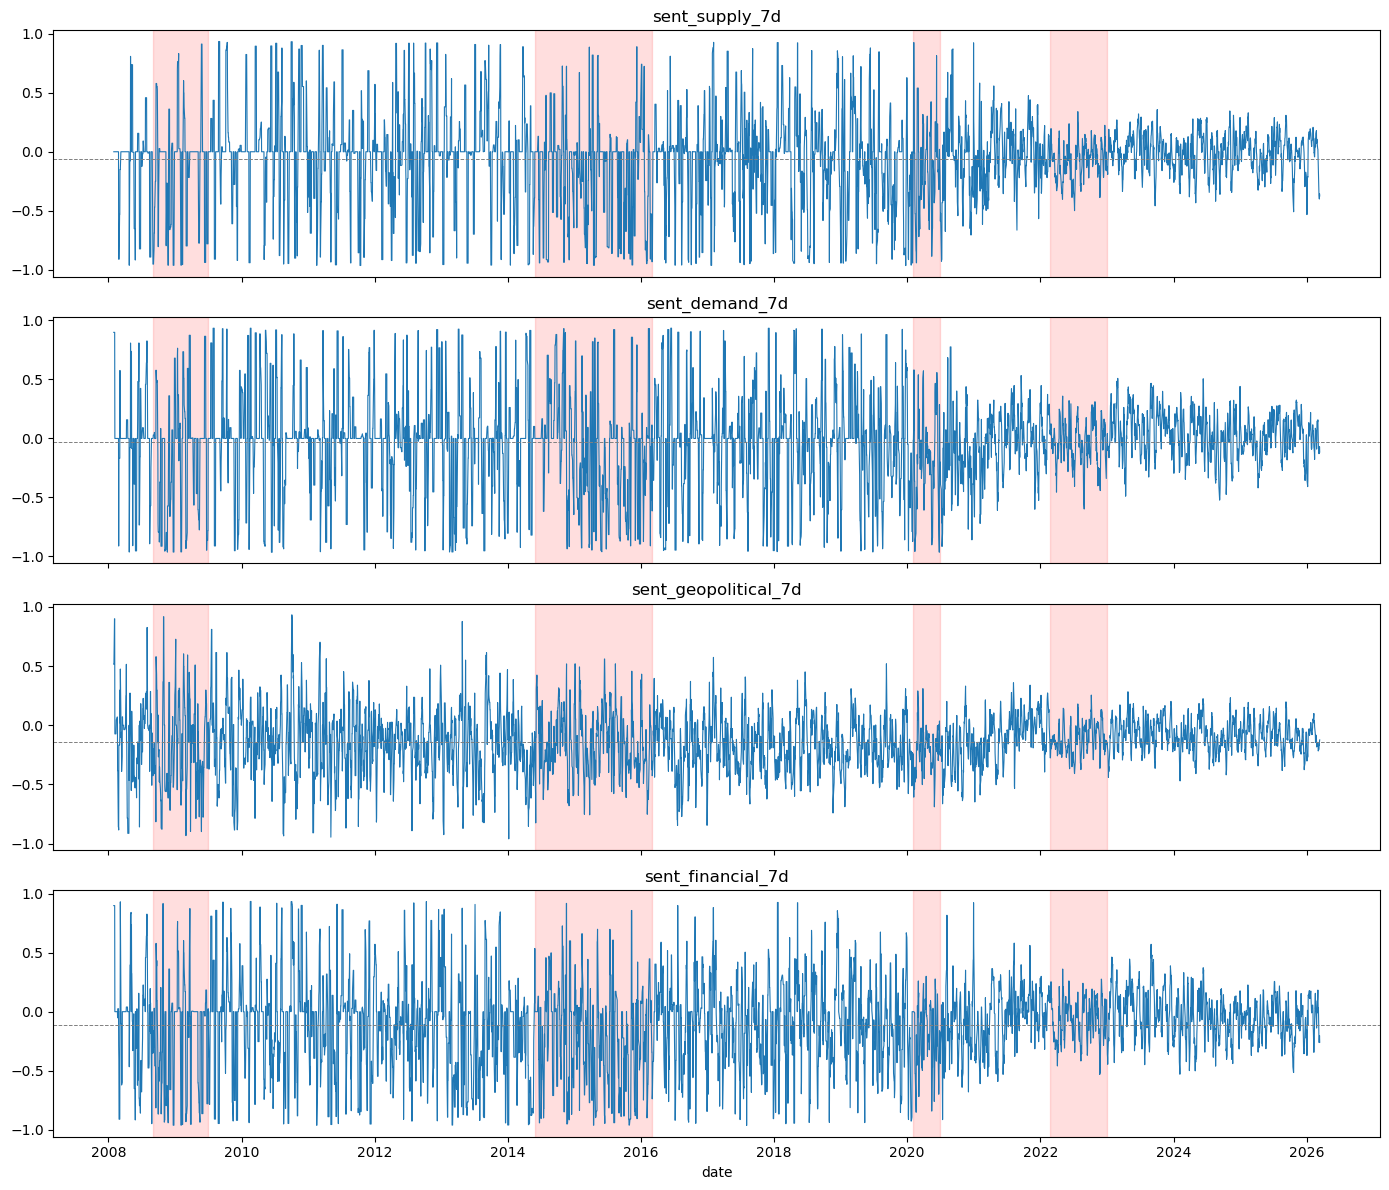

In [6]:
# ── EDA 3. 감성 피처 시계열 (위기 구간 음영) ──
crisis_periods = {
    "GFC 2008":          ("2008-09-01", "2009-06-30"),
    "Oil crash 2014":    ("2014-06-01", "2016-02-29"),
    "COVID 2020":        ("2020-02-01", "2020-06-30"),
    "Russia-Ukraine 22": ("2022-02-24", "2022-12-31"),
}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, sentiment_all):
    ax.plot(df["date"], df[col], lw=0.8)
    ax.axhline(df[col].mean(), color="gray", lw=0.7, ls="--")
    for _, (s, e) in crisis_periods.items():
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.13, color="red")
    ax.set_title(col)
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()


In [7]:
# ── EDA 4. 정상성 검정 (train 구간 기준, 누수 방지) ──
train_mask = df["date"] < SPLIT_DATE
print(f"split_date: {SPLIT_DATE} | train {train_mask.sum()} / test {(~train_mask).sum()}")

rows = []
for col in sentiment_all:
    s = df.loc[train_mask, col].dropna()
    adf_p = adfuller(s)[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    rows.append({
        "variable": col,
        "ADF_p": adf_p,   "ADF_정상": adf_p < 0.05,
        "KPSS_p": kpss_p, "KPSS_정상": kpss_p > 0.05,
    })
stat_df = pd.DataFrame(rows).round(4)
display(stat_df)
print("판정: ADF p<0.05 (단위근 없음) & KPSS p>0.05 (정상) 이면 정상 시계열")
print("* KPSS_p=0.1은 검정통계량이 표 범위 밖이라는 의미로, 실제 p값은 0.1보다 큼 (= 더 명확히 정상)")


split_date: 2022-07-20 | train 3637 / test 910


,variable,ADF_p,ADF_정상,KPSS_p,KPSS_정상
0,sent_supply_7d,0.0,True,0.1,True
1,sent_demand_7d,0.0,True,0.1,True
2,sent_geopolitical_7d,0.0,True,0.1,True
3,sent_financial_7d,0.0,True,0.1,True


판정: ADF p<0.05 (단위근 없음) & KPSS p>0.05 (정상) 이면 정상 시계열
* KPSS_p=0.1은 검정통계량이 표 범위 밖이라는 의미로, 실제 p값은 0.1보다 큼 (= 더 명확히 정상)


감성 피처 vs oil_diff_target 상관계수:


,corr
sent_supply_7d,0.0047
sent_demand_7d,0.0104
sent_geopolitical_7d,0.0016
sent_financial_7d,0.0118


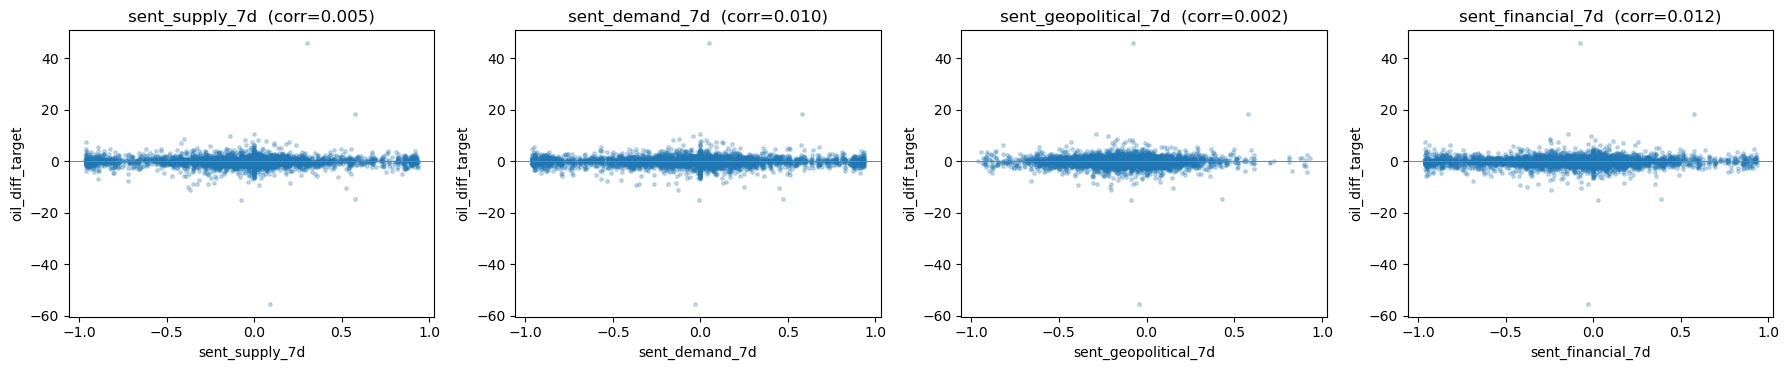

In [8]:
# ── EDA 5. 감성 피처 vs 타겟 관계 ──
corr_t = df[sentiment_all + [TARGET]].corr()[TARGET].drop(TARGET).round(4)
print(f"감성 피처 vs {TARGET} 상관계수:")
display(corr_t.to_frame("corr"))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col in zip(axes, sentiment_all):
    ax.scatter(df[col], df[TARGET], s=6, alpha=0.25)
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.set_title(f"{col}  (corr={corr_t[col]:.3f})")
plt.tight_layout()
plt.show()


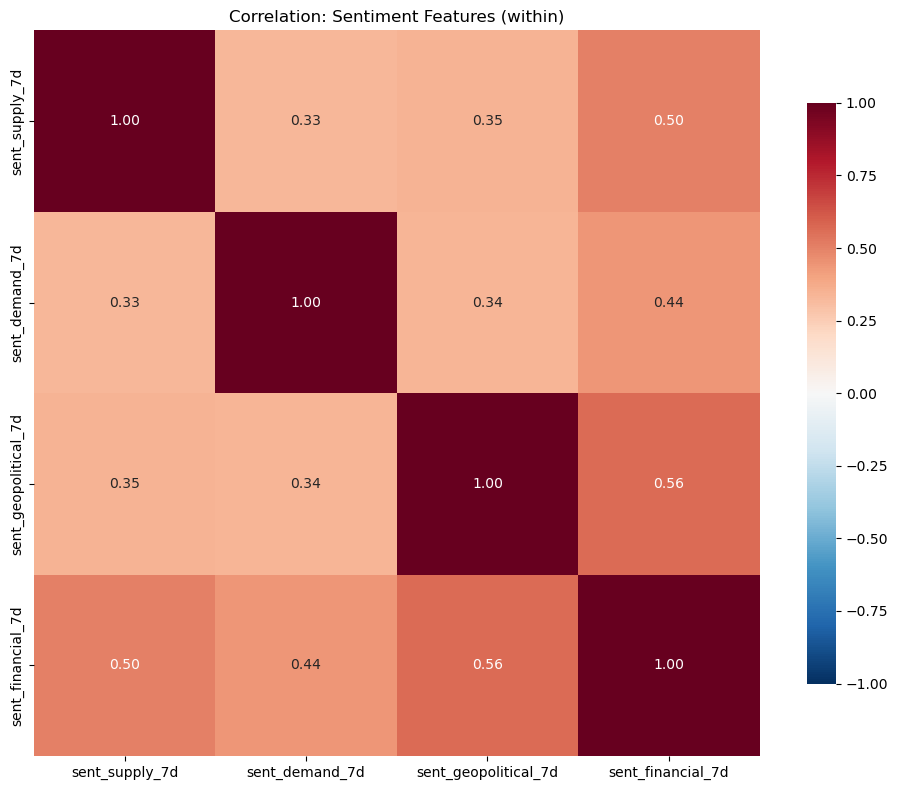

In [9]:
# 2-1. sentiment 변수끼리
corr_sent = df[sentiment_all].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_sent, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation: Sentiment Features (within)")
plt.tight_layout(); plt.show()

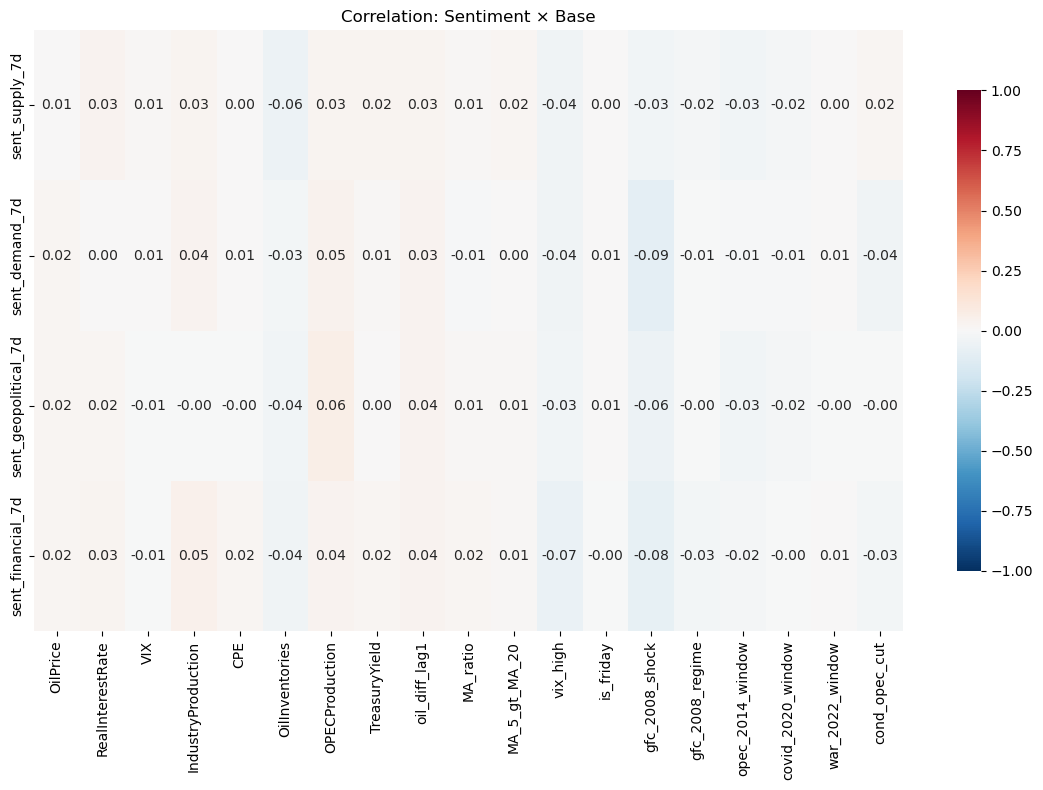

In [10]:
# 2-2. sentiment × base
corr_cross = df[sentiment_all + base_cols].corr().loc[sentiment_all, base_cols]

fig, ax = plt.subplots(figsize=(max(8, len(base_cols)*0.6), 8))
sns.heatmap(corr_cross, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation: Sentiment × Base")
plt.tight_layout(); plt.show()

In [11]:
# 2-3. |r| > 0.7 강한 상관 쌍 추출
THRESHOLD = 0.7

all_cols  = sentiment_all + base_cols
corr_full = df[all_cols].corr().abs()

mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
corr_pairs = (
    corr_full.where(mask).stack().reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
)
corr_pairs = corr_pairs[corr_pairs["abs_corr"] > THRESHOLD].sort_values("abs_corr", ascending=False)
display(corr_pairs.head(30))

,var1,var2,abs_corr
133,IndustryProduction,CPE,0.771846


In [12]:
def compute_vif(X: pd.DataFrame) -> pd.Series:
    X_clean = X.dropna()
    if X_clean.shape[0] < X_clean.shape[1] + 5:
        raise ValueError(f"표본 부족: rows={X_clean.shape[0]}, cols={X_clean.shape[1]}")
    Xc = add_constant(X_clean, has_constant="add")
    vifs = pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
        index=Xc.columns
    )
    return vifs.drop("const").sort_values(ascending=False)

vif_base = compute_vif(df[base_cols])
vif_full = compute_vif(df[base_cols + sentiment_all])

vif_compare = pd.concat(
    [vif_base.rename("VIF_base"), vif_full.rename("VIF_full")],
    axis=1
)
vif_compare["delta"] = vif_compare["VIF_full"] - vif_compare["VIF_base"]
vif_compare = vif_compare.sort_values("VIF_full", ascending=False).round(2)
display(vif_compare)

# 판정: VIF > 10 심각 / > 5 주의
print("\n=== VIF > 10 ===")
display(vif_compare[vif_compare["VIF_full"] > 10])
print("\n=== VIF 5~10 ===")
display(vif_compare[(vif_compare["VIF_full"] > 5) & (vif_compare["VIF_full"] <= 10)])

,VIF_base,VIF_full,delta
CPE,3.99,4.00,0.02
IndustryProduction,2.96,2.97,0.01
OPECProduction,2.38,2.40,0.02
MA_ratio,2.20,2.21,0.01
sent_financial_7d,NaN,1.87,NaN
vix_high,1.84,1.84,0.00
MA_5_gt_MA_20,1.73,1.73,0.00
cond_opec_cut,1.70,1.71,0.01
sent_geopolitical_7d,NaN,1.52,NaN
gfc_2008_regime,1.47,1.47,0.00



=== VIF > 10 ===


,VIF_base,VIF_full,delta



=== VIF 5~10 ===


,VIF_base,VIF_full,delta


In [13]:
def condition_number(X: pd.DataFrame) -> float:
    Xs = (X - X.mean()) / X.std()  # 표준화 후 계산
    Xs = Xs.dropna()
    return cond(Xs.values)

cn_base = condition_number(df[base_cols])
cn_full = condition_number(df[base_cols + sentiment_all])

print(f"Condition Number (Base)        : {cn_base:>10.1f}")
print(f"Condition Number (Base+Sent)   : {cn_full:>10.1f}")
print(f"증가폭                          : {cn_full - cn_base:>10.1f}")

# 판정: CN > 30 다중공선성 우려 / > 100 심각

Condition Number (Base)        :        4.1
Condition Number (Base+Sent)   :        4.2
증가폭                          :        0.1


In [14]:
# 각 sentiment 변수가 base 변수로 얼마나 설명되는가
# R² 높으면 → 해당 sentiment 변수는 base 변수들의 선형결합과 거의 같음 (중복 정보)

import statsmodels.api as sm

partial_r2 = []
for sv in sentiment_all:
    y = df[sv]
    X = df[base_cols + [c for c in sentiment_all if c != sv]]
    valid = y.notna() & X.notna().all(axis=1)
    if valid.sum() < 100:
        continue
    model = sm.OLS(y[valid], add_constant(X[valid])).fit()
    partial_r2.append({"sentiment_var": sv, "R²_by_others": model.rsquared, "VIF_equiv": 1/(1-model.rsquared)})

partial_df = pd.DataFrame(partial_r2).sort_values("R²_by_others", ascending=False)
display(partial_df.round(3))

# R² > 0.9 → 다른 변수로 거의 완전히 설명됨 (중복)
# R² > 0.8 → 정보 중복 상당

,sentiment_var,R²_by_others,VIF_equiv
3,sent_financial_7d,0.465,1.869
2,sent_geopolitical_7d,0.340,1.516
0,sent_supply_7d,0.277,1.383
1,sent_demand_7d,0.229,1.297


In [15]:
def diagnose(row):
    vif = row["VIF_full"]
    if vif > 10: return "🔴 심각 (제거/변환 권장)"
    if vif > 5:  return "🟡 주의 (검토)"
    return "🟢 양호"

vif_compare["판정"] = vif_compare.apply(diagnose, axis=1)
display(vif_compare)

print("\n[종합 권고]")
print(f"- Condition Number: {cn_base:.0f} → {cn_full:.0f} ({'악화' if cn_full > cn_base*1.5 else '유지'})")
print(f"- VIF > 10 변수 수: {(vif_compare['VIF_full'] > 10).sum()}")
print(f"- 강한 상관(|r|>0.7) 쌍: {len(corr_pairs)}")

,VIF_base,VIF_full,delta,판정
CPE,3.99,4.00,0.02,🟢 양호
IndustryProduction,2.96,2.97,0.01,🟢 양호
OPECProduction,2.38,2.40,0.02,🟢 양호
MA_ratio,2.20,2.21,0.01,🟢 양호
sent_financial_7d,NaN,1.87,NaN,🟢 양호
vix_high,1.84,1.84,0.00,🟢 양호
MA_5_gt_MA_20,1.73,1.73,0.00,🟢 양호
cond_opec_cut,1.70,1.71,0.01,🟢 양호
sent_geopolitical_7d,NaN,1.52,NaN,🟢 양호
gfc_2008_regime,1.47,1.47,0.00,🟢 양호



[종합 권고]
- Condition Number: 4 → 4 (유지)
- VIF > 10 변수 수: 0
- 강한 상관(|r|>0.7) 쌍: 1


## 모델링 — OLS 예측 (baseline vs +sentiment)

모델링1에서 확정한 19개 `final_aic_features`를 base로 **고정**하고,
뉴스 감성 4개를 보조피처로 추가한 모델과 성능을 비교한다.

- **baseline**: base 19개
- **+sentiment**: base 19개 + 감성 4개 = 23개
- 변수 선택(AIC) 재실행 없음 — 두 모델의 차이는 오직 감성 피처 유무
- split_date 기준 시간순 train/test 분리, 감성 추가로 test RMSE/방향정확도가 개선되는지 확인


In [16]:
# ── train/test 분리 (split_date 기준) ──
SPLIT_TS = pd.Timestamp(SPLIT_DATE)
train = df[df["date"] <  SPLIT_TS].reset_index(drop=True)
test  = df[df["date"] >= SPLIT_TS].reset_index(drop=True)

print(f"train: {train['date'].min().date()} ~ {train['date'].max().date()} | n = {len(train)}")
print(f"test : {test['date'].min().date()} ~ {test['date'].max().date()} | n = {len(test)}")

y_train, y_test = train[TARGET], test[TARGET]

# 두 가지 피처셋 (상수항 포함)
X_train_base = sm.add_constant(train[base_cols],  has_constant="add")
X_test_base  = sm.add_constant(test[base_cols],   has_constant="add")
X_train_sent = sm.add_constant(train[model_cols], has_constant="add")
X_test_sent  = sm.add_constant(test[model_cols],  has_constant="add")

print(f"\nbaseline  X: {X_train_base.shape}  (base {len(base_cols)})")
print(f"+sentiment X: {X_train_sent.shape}  (base {len(base_cols)} + 감성 {len(sentiment_all)})")


train: 2008-01-31 ~ 2022-07-19 | n = 3637
test : 2022-07-20 ~ 2026-03-13 | n = 910

baseline  X: (3637, 20)  (base 19)
+sentiment X: (3637, 24)  (base 19 + 감성 4)


In [17]:
# ── 평가 함수 ──
def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_pred != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))

def regression_metrics(y_true, y_pred):
    return {
        "RMSE":   float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":    float(mean_absolute_error(y_true, y_pred)),
        "R2":     float(r2_score(y_true, y_pred)),
        "DirAcc": directional_accuracy(y_true, y_pred),
    }

def model_row(name, y_true, y_pred, n_vars):
    return {"model": name, "n_vars": n_vars, **regression_metrics(y_true, y_pred)}


In [18]:
# ── naive 기준선 + OLS 적합 (baseline / +sentiment) ──
# naive
pred_naive_zero = np.zeros(len(y_test))
pred_naive_lag1 = df[TARGET].shift(1)[df["date"] >= SPLIT_TS].fillna(0).values

# OLS — 점추정은 일반 SE로 충분 (예측 비교 목적). 해석/HC3는 interpretation 노트북에서.
ols_base = sm.OLS(y_train, X_train_base).fit()
ols_sent = sm.OLS(y_train, X_train_sent).fit()

pred_base = ols_base.predict(X_test_base).values
pred_sent = ols_sent.predict(X_test_sent).values

print(f"OLS baseline  : train R2={ols_base.rsquared:.4f}, AIC={ols_base.aic:.1f}")
print(f"OLS +sentiment: train R2={ols_sent.rsquared:.4f}, AIC={ols_sent.aic:.1f}")


OLS baseline  : train R2=0.0552, AIC=15617.6
OLS +sentiment: train R2=0.0554, AIC=15624.6


In [19]:
# ── test 성능 비교표 ──
compare = pd.DataFrame([
    model_row("naive_zero",       y_test, pred_naive_zero, 0),
    model_row("naive_lag1",       y_test, pred_naive_lag1, 1),
    model_row("OLS baseline",     y_test, pred_base, len(base_cols)),
    model_row("OLS +sentiment",   y_test, pred_sent, len(model_cols)),
])
compare = compare.round(5)
display(compare.sort_values("RMSE").reset_index(drop=True))

# 감성 추가 효과 (baseline 대비)
b = compare.set_index("model").loc["OLS baseline"]
s = compare.set_index("model").loc["OLS +sentiment"]
print("\n[감성 보조피처 추가 효과 — OLS baseline 대비]")
print(f"  RMSE   : {b['RMSE']:.5f} -> {s['RMSE']:.5f}  ({s['RMSE']-b['RMSE']:+.5f})")
print(f"  MAE    : {b['MAE']:.5f} -> {s['MAE']:.5f}  ({s['MAE']-b['MAE']:+.5f})")
print(f"  DirAcc : {b['DirAcc']:.5f} -> {s['DirAcc']:.5f}  ({s['DirAcc']-b['DirAcc']:+.5f})")
print("  * RMSE/MAE는 감소(-), DirAcc는 증가(+)가 개선")


,model,n_vars,RMSE,MAE,R2,DirAcc
0,naive_zero,0,1.70028,1.25826,-0.00005,NaN
1,OLS baseline,19,1.75830,1.29644,-0.06946,0.49560
2,OLS +sentiment,23,1.75888,1.29661,-0.07016,0.49011
3,naive_lag1,1,2.32838,1.77543,-0.87537,0.50220



[감성 보조피처 추가 효과 — OLS baseline 대비]
  RMSE   : 1.75830 -> 1.75888  (+0.00058)
  MAE    : 1.29644 -> 1.29661  (+0.00017)
  DirAcc : 0.49560 -> 0.49011  (-0.00549)
  * RMSE/MAE는 감소(-), DirAcc는 증가(+)가 개선


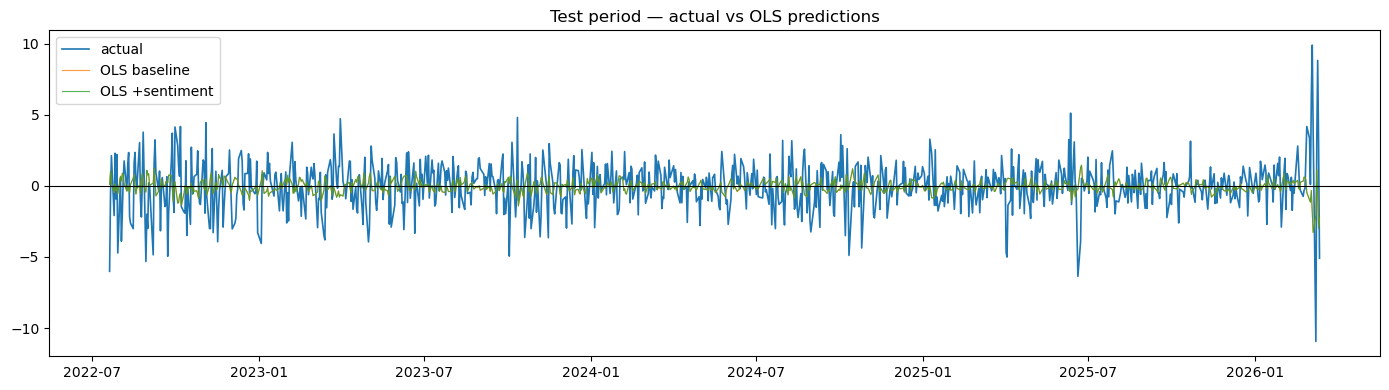

In [20]:
# ── test 구간 예측 시각화 ──
plt.figure(figsize=(14, 4))
plt.plot(test["date"], y_test.values,  label="actual",        lw=1.2)
plt.plot(test["date"], pred_base,       label="OLS baseline",  lw=0.8, alpha=0.8)
plt.plot(test["date"], pred_sent,       label="OLS +sentiment",lw=0.8, alpha=0.8)
plt.axhline(0, lw=0.8, color="black")
plt.title("Test period — actual vs OLS predictions")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# ── TimeSeriesSplit CV (train 내부, baseline vs +sentiment) ──
tscv = TimeSeriesSplit(n_splits=5)

def cv_eval(feature_cols, name):
    rows = []
    for k, (tr, va) in enumerate(tscv.split(train), 1):
        Xtr = sm.add_constant(train.iloc[tr][feature_cols], has_constant="add")
        Xva = sm.add_constant(train.iloc[va][feature_cols], has_constant="add")
        ytr, yva = train.iloc[tr][TARGET], train.iloc[va][TARGET]
        m = sm.OLS(ytr, Xtr).fit()
        rows.append({"fold": k, **regression_metrics(yva, m.predict(Xva))})
    cvd = pd.DataFrame(rows)
    mean = cvd[["RMSE","MAE","R2","DirAcc"]].mean()
    return cvd, mean

cv_base, mean_base = cv_eval(base_cols,  "baseline")
cv_sent, mean_sent = cv_eval(model_cols, "+sentiment")

cv_summary = pd.DataFrame({"baseline": mean_base, "+sentiment": mean_sent}).round(5)
print("===== TimeSeriesSplit(5) CV 평균 — train 내부 =====")
display(cv_summary)


===== TimeSeriesSplit(5) CV 평균 — train 내부 =====


,baseline,+sentiment
RMSE,1.80389,1.80801
MAE,1.14472,1.14775
R2,-0.02764,-0.03310
DirAcc,0.51155,0.50660


In [22]:
# ── 저장: final_features_v2.json + 비교표 ──
OUT_DIR = Path("../outputs/modeling2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

payload = {
    "target": TARGET,
    "split_date": SPLIT_DATE,
    "base_features": base_cols,
    "sentiment_features": sentiment_all,
    "all_features": model_cols,
    "n_base": len(base_cols),
    "n_sentiment": len(sentiment_all),
    "data_files": {
        "base": "dataset4_derived_full_with_dummies.csv",
        "sentiment": "sentiment_avg_7d_final.csv",
    },
    "note": "base는 모델링1 final_aic_features 고정, 감성 4개 보조피처 추가",
}
with open(OUT_DIR / "final_features_v2.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

compare.to_csv(OUT_DIR / "ols2_prediction_compare.csv", index=False)
cv_summary.to_csv(OUT_DIR / "ols2_cv_summary.csv")

print("저장 완료:")
for fn in ["final_features_v2.json", "ols2_prediction_compare.csv", "ols2_cv_summary.csv"]:
    print(" -", OUT_DIR / fn)


저장 완료:
 - ../outputs/modeling2/final_features_v2.json
 - ../outputs/modeling2/ols2_prediction_compare.csv
 - ../outputs/modeling2/ols2_cv_summary.csv


## 최종결론

OLS Prediction에서는 모델링1에서 선정된 base feature 19개에 감성 피처 4개를 추가하여 test 성능 변화를 비교하였다.

| 모델 | RMSE | MAE | R2 | DirAcc |
|---|---:|---:|---:|---:|
| OLS baseline | 1.75830 | 1.29644 | -0.06946 | 0.49560 |
| OLS +sentiment | 1.75888 | 1.29661 | -0.07016 | 0.49011 |

감성 피처를 추가한 이후 RMSE, MAE, R2, 방향 정확도 모두 소폭 악화되었다. 

따라서 선형 OLS 예측 관점에서는 7일 평균 뉴스 감성 피처가 유가 변화율 예측 성능을 개선하지 못한 것으로 판단된다.